# Comparación de modelos: LightGBM frente a las referencias

**Objetivo:** medir cuánto mejora LightGBM a las previsiones de referencia, dónde gana, dónde falla y si acierta lo que de verdad importa en la web: **cuáles son las horas baratas**.

**Cómo se evalúa** (detalle en `src/models/train.py`):

- **Backtest día a día (walk-forward):** para cada día, los modelos solo ven los precios hasta la víspera, igual que en producción. Hay tests que lo garantizan.
- **Reentrenamiento cada 30 días** con los últimos 2 años de datos disponibles en ese momento.
- **Validación y prueba separadas:** la configuración de LightGBM se eligió con 2024. Aquí se evalúa **solo el periodo de prueba, de enero de 2025 en adelante**, que no se usó para elegir nada.
- **Referencias:** "precio de ayer" (la misma hora del día anterior) y "media 7 días" (la media de esa hora en la última semana).

> Para reproducirlo: `make backfill` y después ejecutar este notebook (el backtest tarda unos 3 minutos).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.ingestion.prices import load_pvpc
from src.models.evaluate import metrics_by_group
from src.models.lightgbm_model import LightGBMForecaster
from src.models.train import TEST_START, compare_models
from src.processing.clean import clean_prices
from src.processing.features import build_features
from src.utils.calendar import local_date, national_holidays

INK, BLUE, AMBER, GREY = "#0E1726", "#1F4E9C", "#E99A1E", "#A9B4C2"
COLORS = {"lightgbm": BLUE, "precio_ayer": AMBER, "media_7_dias": GREY}
NAMES = {"lightgbm": "LightGBM", "precio_ayer": "Precio de ayer", "media_7_dias": "Media 7 días"}
plt.rcParams.update({
    "figure.figsize": (10, 4), "figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "axes.titleweight": "bold", "axes.titlesize": 12,
})
pd.set_option("display.float_format", "{:.1f}".format)

prices = clean_prices(load_pvpc())
end = local_date(prices["price"].dropna().index.max())
summary, results = compare_models(prices, TEST_START, end)

predictions = pd.DataFrame({name: r["prediction"] for name, r in results.items()})
real = results["lightgbm"]["price"]
day = results["lightgbm"]["day"]
local = predictions.index.tz_convert("Europe/Madrid")
errors = predictions.sub(real, axis=0)
n_hours = f"{len(real):,}".replace(",", ".")
print(f"Periodo de prueba: del {TEST_START:%d/%m/%Y} al {end:%d/%m/%Y}, {n_hours} horas")

Periodo de prueba: del 01/01/2025 al 06/10/2026, 15.455 horas


## 1. Resultado global

In [2]:
table = summary.rename(index=NAMES).rename(columns={"mae": "MAE", "rmse": "RMSE", "bias": "sesgo", "n": "horas"})
best_reference = summary.drop("lightgbm")["mae"].min()
print(f"LightGBM reduce el error medio un {(1 - summary.loc['lightgbm', 'mae'] / best_reference) * 100:.0f} % frente a la mejor referencia")
table

LightGBM reduce el error medio un 44 % frente a la mejor referencia


,MAE,RMSE,sesgo,horas
modelo,,,,
LightGBM,16.0,22.4,-1.0,15455
Precio de ayer,28.5,44.7,-0.0,15455
Media 7 días,28.9,39.1,-0.0,15455


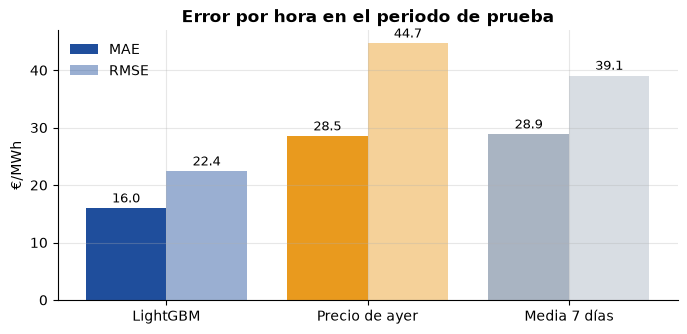

In [3]:
fig, ax = plt.subplots(figsize=(8, 3.5))
x = np.arange(len(summary))
ax.bar(x - 0.2, summary["mae"], 0.4, color=[COLORS[m] for m in summary.index], label="MAE")
ax.bar(x + 0.2, summary["rmse"], 0.4, color=[COLORS[m] for m in summary.index], alpha=0.45, label="RMSE")
for i, (mae, rmse) in enumerate(zip(summary["mae"], summary["rmse"], strict=True)):
    ax.text(i - 0.2, mae + 1, f"{mae:.1f}", ha="center", fontsize=9)
    ax.text(i + 0.2, rmse + 1, f"{rmse:.1f}", ha="center", fontsize=9)
ax.set_xticks(x, [NAMES[m] for m in summary.index])
ax.set(title="Error por hora en el periodo de prueba", ylabel="€/MWh")
ax.legend(frameon=False)
plt.show()

LightGBM falla de media **16,0 €/MWh** por hora, frente a 28,5 de "precio de ayer": **un 44 % menos**. El RMSE, que castiga los errores grandes, baja a la mitad (de 44,7 a 22,4). Ninguno de los tres modelos tiene un sesgo apreciable en el conjunto del periodo.

Durante la validación (2024) LightGBM obtuvo 15,6 €/MWh: el resultado se mantiene en un periodo que no se usó para ajustarlo, así que **no está sobreajustado**.

## 2. Una semana de ejemplo

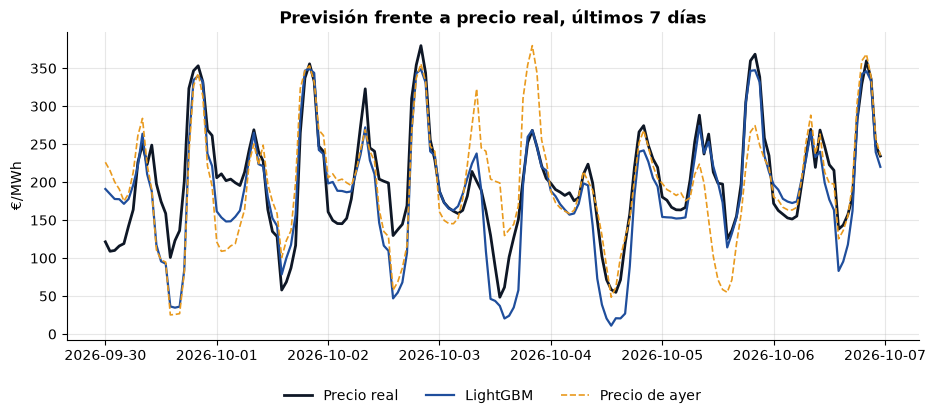

In [4]:
last_week = local >= (pd.Timestamp(end) - pd.Timedelta(days=6)).tz_localize("Europe/Madrid")
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(local[last_week], real[last_week], color=INK, lw=2, label="Precio real")
ax.plot(local[last_week], predictions.loc[last_week, "lightgbm"], color=BLUE, lw=1.6, label="LightGBM")
ax.plot(local[last_week], predictions.loc[last_week, "precio_ayer"], color=AMBER, lw=1.2, ls="--", label="Precio de ayer")
ax.set(title="Previsión frente a precio real, últimos 7 días", ylabel="€/MWh")
ax.legend(frameon=False, ncols=3, loc="upper center", bbox_to_anchor=(0.5, -0.12))
plt.show()

LightGBM sigue la forma de cada día: el valle de mediodía y el pico de la tarde. "Precio de ayer" va siempre un día por detrás, y se nota sobre todo al pasar de fin de semana a laborable.

## 3. Error por hora del día

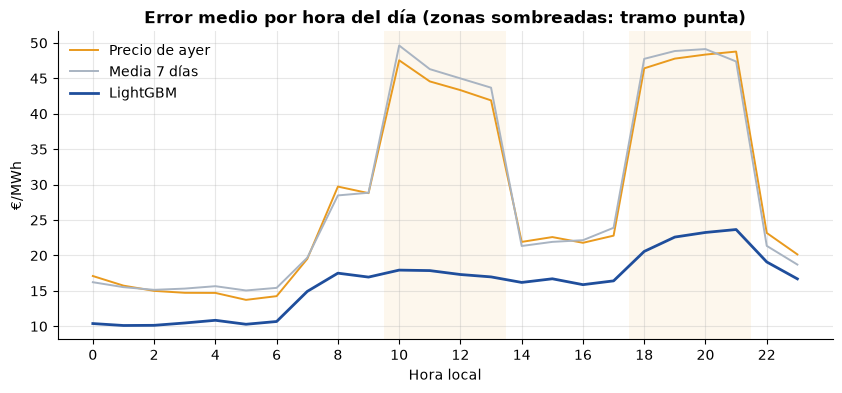

In [5]:
by_hour = pd.DataFrame({NAMES[m]: metrics_by_group(real, predictions[m], pd.Series(local.hour, name="hora"))["mae"] for m in predictions})
fig, ax = plt.subplots()
for start, stop in [(10, 14), (18, 22)]:
    ax.axvspan(start - 0.5, stop - 0.5, color=AMBER, alpha=0.08, lw=0)
for m in predictions:
    ax.plot(by_hour.index, by_hour[NAMES[m]], color=COLORS[m], lw=2 if m == "lightgbm" else 1.4, label=NAMES[m])
ax.set(title="Error medio por hora del día (zonas sombreadas: tramo punta)", xlabel="Hora local", ylabel="€/MWh", xticks=range(0, 24, 2))
ax.legend(frameon=False)
plt.show()

Las referencias fallan mucho más en las **horas punta** (10–14 h y 18–22 h): en fin de semana no hay tramo punta, así que el lunes a esas horas no se parece al domingo. LightGBM falla menos en todas las horas y, en las horas punta, reduce el error a menos de la mitad (de 42–50 a 17–24 €/MWh).

## 4. Error por día de la semana

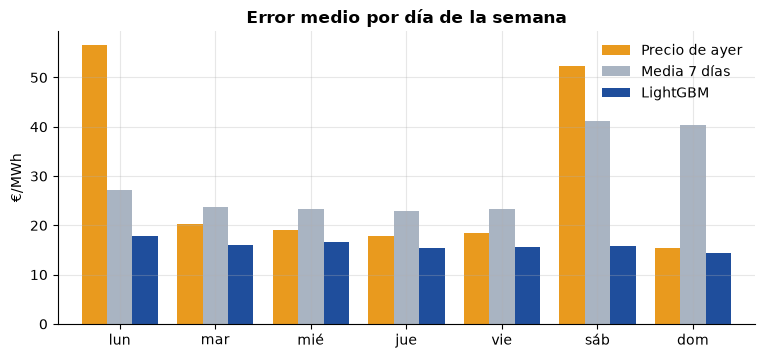

,lun,mar,mié,jue,vie,sáb,dom
Precio de ayer,56.5,20.2,19.0,17.8,18.4,52.2,15.4
Media 7 días,27.2,23.8,23.3,22.9,23.3,41.2,40.3
LightGBM,17.9,16.0,16.7,15.4,15.5,15.8,14.5


In [6]:
weekday_names = ["lun", "mar", "mié", "jue", "vie", "sáb", "dom"]
by_weekday = pd.DataFrame({NAMES[m]: metrics_by_group(real, predictions[m], pd.Series(local.dayofweek, name="día"))["mae"] for m in predictions})
by_weekday.index = weekday_names
ax = by_weekday.plot.bar(color=[COLORS[m] for m in predictions], figsize=(9, 3.8), rot=0, width=0.8)
ax.set(title="Error medio por día de la semana", ylabel="€/MWh")
ax.legend(frameon=False)
plt.show()
by_weekday.T

Es la diferencia más clara: **"precio de ayer" se dispara los lunes y los sábados** (más de 50 €/MWh), cuando se pasa de laborable a fin de semana o al revés. LightGBM se mantiene estable toda la semana porque sabe qué día es y usa el precio del mismo día de la semana anterior.

## 5. Estabilidad en el tiempo

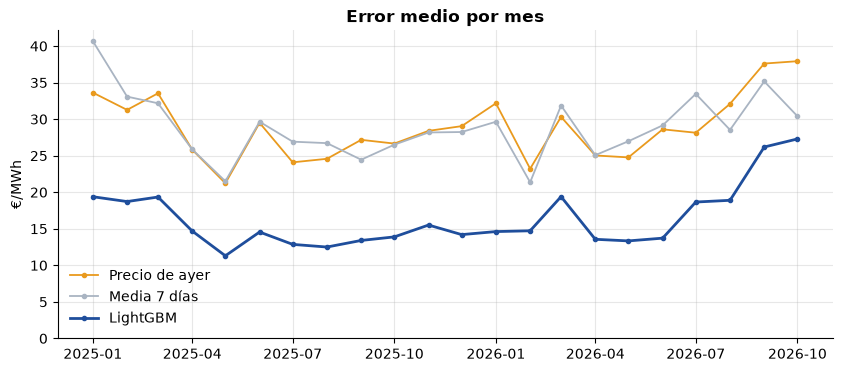

In [7]:
monthly = errors.abs().groupby([local.year, local.month]).mean()
monthly.index = [pd.Timestamp(year=y, month=m, day=1) for y, m in monthly.index]
fig, ax = plt.subplots()
for m in predictions:
    ax.plot(monthly.index, monthly[m], marker="o", ms=3, color=COLORS[m], lw=2 if m == "lightgbm" else 1.3, label=NAMES[m])
ax.set(title="Error medio por mes", ylabel="€/MWh", ylim=(0, None))
ax.legend(frameon=False)
plt.show()

LightGBM mejora a las referencias **todos los meses**. Su error se mantiene entre 11 y 19 €/MWh en 2025 y sube en septiembre y octubre de 2026, cuando el precio se volvió mucho más volátil (como se vio en el notebook 01). Esos meses también empeoran las referencias.

## 6. Distribución de los errores y días más difíciles

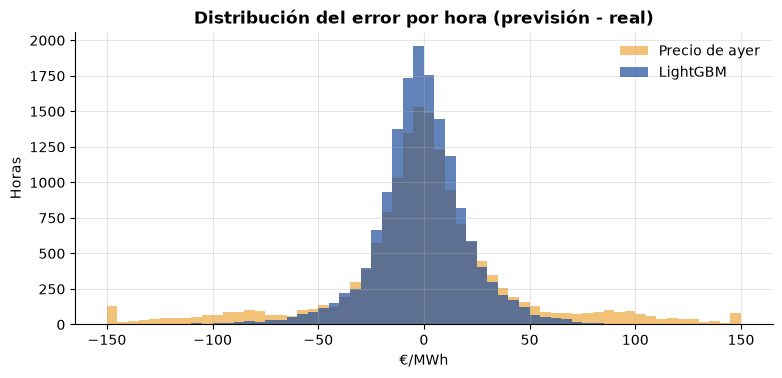

,a menos de 10 €/MWh,a menos de 20 €/MWh,a más de 50 €/MWh
% de horas,,,
Precio de ayer,36 %,59 %,17 %
Media 7 días,28 %,49 %,18 %
LightGBM,45 %,73 %,4 %


In [8]:
fig, ax = plt.subplots(figsize=(9, 3.8))
bins = np.arange(-150, 151, 5)
ax.hist(errors["precio_ayer"].clip(-150, 150), bins=bins, color=AMBER, alpha=0.6, label="Precio de ayer")
ax.hist(errors["lightgbm"].clip(-150, 150), bins=bins, color=BLUE, alpha=0.7, label="LightGBM")
ax.set(title="Distribución del error por hora (previsión - real)", xlabel="€/MWh", ylabel="Horas")
ax.legend(frameon=False)
plt.show()

shares = pd.DataFrame({
    NAMES[m]: {
        "a menos de 10 €/MWh": (errors[m].abs() <= 10).mean() * 100,
        "a menos de 20 €/MWh": (errors[m].abs() <= 20).mean() * 100,
        "a más de 50 €/MWh": (errors[m].abs() > 50).mean() * 100,
    } for m in predictions
}).T
shares.map("{:.0f} %".format).rename_axis("% de horas")

In [9]:
daily_mae = errors.abs().groupby(day).mean()
worst = daily_mae["lightgbm"].nlargest(6).index
pd.DataFrame({
    "día": [f"{d:%d/%m/%Y} ({weekday_names[d.weekday()]})" for d in worst],
    "festivo": ["sí" if d in national_holidays(d.year) else "" for d in worst],
    "LightGBM": daily_mae.loc[worst, "lightgbm"].to_numpy(),
    "Precio de ayer": daily_mae.loc[worst, "precio_ayer"].to_numpy(),
}).set_index("día")

,festivo,LightGBM,Precio de ayer
día,,,
28/09/2026 (lun),,63.5,111.6
30/09/2026 (mié),,52.1,63.8
01/01/2025 (mié),sí,45.8,71.8
16/03/2026 (lun),,43.1,61.8
02/10/2026 (vie),,42.4,39.3
29/09/2026 (mar),,40.6,70.6


- **Errores grandes:** con LightGBM, solo el 4 % de las horas falla más de 50 €/MWh, frente al 17 % de "precio de ayer". La distribución es mucho más estrecha.
- **Días más difíciles:** se concentran a finales de septiembre de 2026, el periodo más volátil de la serie, y en festivos como el 1 de enero. En casi todos ellos LightGBM sigue fallando bastante menos que la referencia.

## 7. ¿Acierta las horas baratas?

La web no necesita el precio exacto: necesita saber **cuándo** poner la lavadora. Se mide así: si eliges la hora (o la ventana de 2 horas) que el modelo da como más barata, ¿cuánto más pagas que en la más barata real?

In [10]:
def cheapest_hour_metrics(prediction):
    rows = []
    for _, g in pd.DataFrame({"real": real, "pred": prediction, "day": day}).groupby("day"):
        g = g.reset_index(drop=True)
        chosen = g["pred"].idxmin()
        window_pred = g["pred"].rolling(2).mean().shift(-1).idxmin()
        window_real = g["real"].rolling(2).mean().shift(-1).idxmin()
        rows.append({
            "hora exacta": g["real"].rank()[chosen] == 1,
            "entre las 3 más baratas": g["real"].rank()[chosen] <= 3,
            "sobrecoste hora (€/MWh)": g.loc[chosen, "real"] - g["real"].min(),
            "sobrecoste ventana 2 h (€/MWh)": g["real"].iloc[window_pred:window_pred + 2].mean()
                                             - g["real"].iloc[window_real:window_real + 2].mean(),
        })
    out = pd.DataFrame(rows).mean()
    out[["hora exacta", "entre las 3 más baratas"]] *= 100
    return out

cheapest = pd.DataFrame({NAMES[m]: cheapest_hour_metrics(predictions[m]) for m in predictions}).T
for column in ["hora exacta", "entre las 3 más baratas"]:
    cheapest[column] = cheapest[column].map("{:.0f} %".format)
cheapest

,hora exacta,entre las 3 más baratas,sobrecoste hora (€/MWh),sobrecoste ventana 2 h (€/MWh)
Precio de ayer,33 %,62 %,13.8,12.3
Media 7 días,37 %,72 %,4.6,4.1
LightGBM,33 %,73 %,3.5,2.6


- Usando la hora más barata según LightGBM pagas de media **3,5 €/MWh** más que en la más barata real, frente a 13,8 con "precio de ayer". En una ventana de 2 horas, **2,6** frente a 12,3.
- En el **73 % de los días**, la hora elegida está entre las 3 más baratas reales.
- Curiosidad: "media 7 días" es casi tan buena como LightGBM eligiendo la hora, aunque falla mucho más en el precio. Promediar una semana conserva bien la forma del día.

→ **Para la web:** el simulador y el planificador pueden apoyarse en la previsión de LightGBM con un sobrecoste pequeño frente a saber el futuro.

## 8. Sesgo por hora: dónde se queda corto

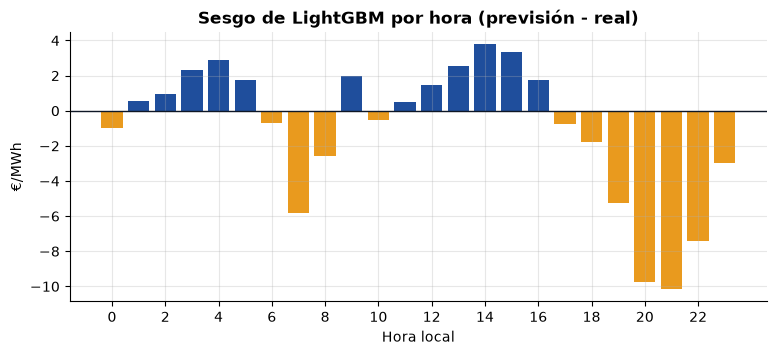

In [11]:
bias = errors["lightgbm"].groupby(local.hour).mean()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(bias.index, bias, color=[AMBER if v < 0 else BLUE for v in bias])
ax.axhline(0, color=INK, lw=1)
ax.set(title="Sesgo de LightGBM por hora (previsión - real)", xlabel="Hora local", ylabel="€/MWh", xticks=range(0, 24, 2))
plt.show()

LightGBM **se queda corto en el pico de la tarde** (unos −10 €/MWh a las 20–21 h) y se pasa a mediodía (+3 a +4 €/MWh). Tiende a suavizar los extremos, algo típico de un modelo que minimiza el error absoluto con pocas variables que anticipen esos picos.

→ **Mejora prevista:** las previsiones de demanda, eólica y solar de REE (mejora 9.2) deberían ayudar justo aquí.

## 9. Qué variables usa el modelo

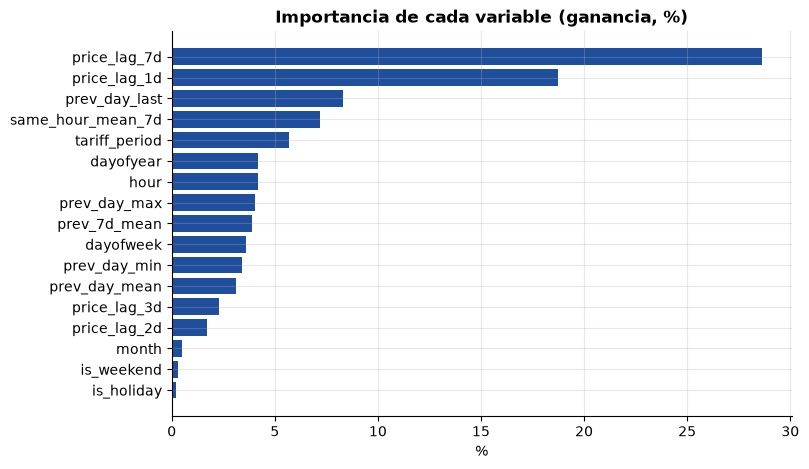

In [12]:
model = LightGBMForecaster()
model.fit(build_features(prices))
importance = model.feature_importance()
importance = importance / importance.sum() * 100
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(importance.index[::-1], importance[::-1], color=BLUE)
ax.set(title="Importancia de cada variable (ganancia, %)", xlabel="%")
plt.show()

La variable más importante es **`price_lag_7d`**, el precio a la misma hora del mismo día de la semana anterior: es lo que resuelve el problema de los lunes y los sábados. Le siguen el precio de ayer a esa hora y el último precio conocido de la víspera. El calendario (`tariff_period`, `hour`, `dayofweek`) aporta la forma del día.

## Conclusiones

| Pregunta | Respuesta |
|---|---|
| ¿Mejora LightGBM a las referencias? | Sí: **16,0 frente a 28,5 €/MWh (−44 %)**, todos los meses y en todas las horas |
| ¿Está sobreajustado? | No: 15,6 en validación (2024) y 16,0 en prueba (desde 2025) |
| ¿Dónde ganaba poco una referencia? | Lunes y sábados, en horas punta: LightGBM lo resuelve con el retardo de 7 días y el calendario |
| ¿Acierta las horas baratas? | Sí: sobrecoste de 3,5 €/MWh al elegir la hora más barata (13,8 con "precio de ayer") |
| ¿Dónde falla? | Suaviza los extremos: se queda corto en el pico de la tarde y empeora en periodos muy volátiles |

**Siguientes pasos para el modelo:**

1. Añadir el mix de generación del día anterior (notebook 02).
2. Usar las previsiones de demanda, eólica y solar de REE para el día siguiente (mejora 9.2), para anticipar picos.
3. Intervalos de predicción (mejora 9.3), para que la web muestre la incertidumbre en los días volátiles.